# Visualizations of loss Function

In [2]:
import sys
import os
main_dir = os.path.dirname(os.getcwd())
sys.path.append(main_dir)

import argparse
import os
import time

import numpy as np

from MambaCD.changedetection.configs.config import get_config

import torch
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
from MambaCD.changedetection.datasets.make_data_loader import SemanticChangeDetectionDatset, make_data_loader
from MambaCD.changedetection.utils_func.metrics import Evaluator
from MambaCD.changedetection.models.STMambaSCD import STMambaSCD
import MambaCD.changedetection.utils_func.lovasz_loss as L
from torch.optim.lr_scheduler import StepLR
from MambaCD.changedetection.utils_func.mcd_utils import accuracy, SCDD_eval_all, AverageMeter

from ChangeDetection.CDlib.loss import ce2_dice1, ce2_dice1_multiclass
import matplotlib.pyplot as plt

In [3]:
torch.cuda.set_device(1)

In [13]:
MODEL_PATH = os.path.join(
    main_dir, "MambaCD/saved_models/SECOND/MambaSCD_1738611602.5036116/12000_model.pth"
)

In [14]:
configs_path = os.path.join(main_dir, 'MambaCD/changedetection/configs/vssm1/vssm_small_224.yaml')
model_path = os.path.join(main_dir, 'MambaCD/saved_models')

SECOND_DATASET_PATH = os.path.join(main_dir, 'Datasets', 'SECOND')
SECOND_TRAIN_DATASET_PATH = os.path.join(SECOND_DATASET_PATH, 'train')
SECOND_TEST_DATASET_PATH = os.path.join(SECOND_DATASET_PATH, 'test')
SECOND_TRAIN_DATA_LIST_PATH = os.path.join(SECOND_DATASET_PATH, 'train.txt')
SECOND_TEST_DATA_LIST_PATH = os.path.join(SECOND_DATASET_PATH, 'test.txt')

train_data_list = []
with open(SECOND_TRAIN_DATA_LIST_PATH, 'r') as f:
    for line in f:
        train_data_list.append(line.strip())

test_data_list = []
with open(SECOND_TEST_DATA_LIST_PATH, 'r') as f:
    for line in f:
        test_data_list.append(line.strip())

class ARGS:
    def __init__(self):
        self.cfg = configs_path
        self.opts = None
        self.pretrained_weight_path = MODEL_PATH
        self.dataset = 'SECOND'
        self.type = 'train'
        self.train_dataset_path = SECOND_TRAIN_DATASET_PATH
        self.train_data_list_path = SECOND_TRAIN_DATA_LIST_PATH
        self.test_dataset_path = SECOND_TEST_DATASET_PATH
        self.test_data_list_path = SECOND_TEST_DATA_LIST_PATH
        self.shuffle = True
        self.batch_size = 1
        self.crop_size = 512
        self.train_data_name_list = train_data_list
        self.test_data_name_list = test_data_list
        self.start_iter = 0
        self.cuda = True
        self.max_iters = 400000
        self.model_type = 'MambaSCD'
        self.model_param_path = model_path
        self.resume = None
        self.learning_rate = 1e-4
        self.momentum = 0.9
        self.weight_decay = 5e-4

args = ARGS()

In [15]:
args = args
config = get_config(args)

train_data_loader = make_data_loader(args)

deep_model = STMambaSCD(
    output_cd = 2, 
    output_clf = 7,
    pretrained=args.pretrained_weight_path,
    patch_size=config.MODEL.VSSM.PATCH_SIZE, 
    in_chans=config.MODEL.VSSM.IN_CHANS, 
    num_classes=config.MODEL.NUM_CLASSES, 
    depths=config.MODEL.VSSM.DEPTHS, 
    dims=config.MODEL.VSSM.EMBED_DIM, 
    # ===================
    ssm_d_state=config.MODEL.VSSM.SSM_D_STATE,
    ssm_ratio=config.MODEL.VSSM.SSM_RATIO,
    ssm_rank_ratio=config.MODEL.VSSM.SSM_RANK_RATIO,
    ssm_dt_rank=("auto" if config.MODEL.VSSM.SSM_DT_RANK == "auto" else int(config.MODEL.VSSM.SSM_DT_RANK)),
    ssm_act_layer=config.MODEL.VSSM.SSM_ACT_LAYER,
    ssm_conv=config.MODEL.VSSM.SSM_CONV,
    ssm_conv_bias=config.MODEL.VSSM.SSM_CONV_BIAS,
    ssm_drop_rate=config.MODEL.VSSM.SSM_DROP_RATE,
    ssm_init=config.MODEL.VSSM.SSM_INIT,
    forward_type=config.MODEL.VSSM.SSM_FORWARDTYPE,
    # ===================
    mlp_ratio=config.MODEL.VSSM.MLP_RATIO,
    mlp_act_layer=config.MODEL.VSSM.MLP_ACT_LAYER,
    mlp_drop_rate=config.MODEL.VSSM.MLP_DROP_RATE,
    # ===================
    drop_path_rate=config.MODEL.DROP_PATH_RATE,
    patch_norm=config.MODEL.VSSM.PATCH_NORM,
    norm_layer=config.MODEL.VSSM.NORM_LAYER,
    downsample_version=config.MODEL.VSSM.DOWNSAMPLE,
    patchembed_version=config.MODEL.VSSM.PATCHEMBED,
    gmlp=config.MODEL.VSSM.GMLP,
    use_checkpoint=config.TRAIN.USE_CHECKPOINT,
    ) 

deep_model.load_state_dict(torch.load(MODEL_PATH))
deep_model.cuda()

=> merge config from /userhomes/keshawa17/CD/MambaCD/changedetection/configs/vssm1/vssm_small_224.yaml
Successfully load ckpt /userhomes/keshawa17/CD/MambaCD/saved_models/SECOND/MambaSCD_1738611602.5036116/12000_model.pth
Failed loading checkpoint form /userhomes/keshawa17/CD/MambaCD/saved_models/SECOND/MambaSCD_1738611602.5036116/12000_model.pth: 'model'
False


/tmp/ipykernel_2087408/3711684686.py:40: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  deep_model.load_state_dict(torch.load(MODEL_PATH))


STMambaSCD(
  (encoder): Backbone_VSSM(
    (patch_embed): Sequential(
      (0): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): Permute()
      (2): LayerNorm((48,), eps=1e-05, elementwise_affine=True)
      (3): Permute()
      (4): GELU(approximate='none')
      (5): Conv2d(48, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (6): Permute()
      (7): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    )
    (layers): ModuleList(
      (0): Sequential(
        (blocks): Sequential(
          (0): Conv1DMamba_v2_Encoder(
            (vssmBlock): VSSBlock(
              (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
              (op): SS2D(
                (out_norm): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
                (in_proj): Linear(in_features=96, out_features=192, bias=False)
                (act): SiLU()
                (conv2d): Conv2d(192, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), gro

  0%|          | 0/400000 [00:00<?, ?it/s]

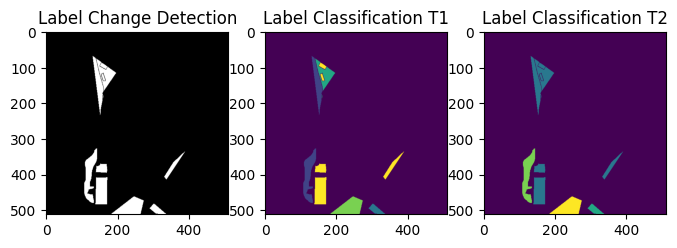

  0%|          | 0/400000 [00:00<?, ?it/s]


In [34]:
elem_num = len(train_data_loader)
train_enumerator = enumerate(train_data_loader)
for _ in tqdm(range(elem_num)):
    itera, data = train_enumerator.__next__()
    pre_change_imgs, post_change_imgs, label_cd, label_clf_t1, label_clf_t2, _ = data

    pre_change_imgs = pre_change_imgs.cuda()
    post_change_imgs = post_change_imgs.cuda()
    label_cd = label_cd.cuda().long()
    label_clf_t1 = label_clf_t1.cuda().long()
    label_clf_t2 = label_clf_t2.cuda().long()

    fig1, axes = plt.subplots(1, 3, figsize=(8, 4))
    axes[0].imshow(label_cd[0].cpu().numpy(), cmap='gray')
    axes[0].set_title('Label Change Detection')
    axes[1].imshow(label_clf_t1[0].cpu().numpy())
    axes[1].set_title('Label Classification T1')
    axes[2].imshow(label_clf_t2[0].cpu().numpy())
    axes[2].set_title('Label Classification T2')
    plt.show()
    break

Text(0.5, 1.0, 'Label Classification T2')

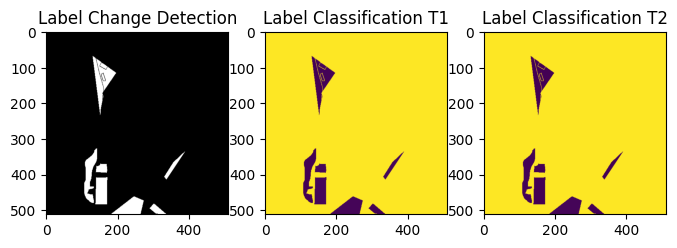

In [35]:
label_clf_t1[label_clf_t1 == 0] = 255
label_clf_t2[label_clf_t2 == 0] = 255

fig1, axes = plt.subplots(1, 3, figsize=(8, 4))
axes[0].imshow(label_cd[0].cpu().numpy(), cmap='gray')
axes[0].set_title('Label Change Detection')
axes[1].imshow(label_clf_t1[0].cpu().numpy())
axes[1].set_title('Label Classification T1')
axes[2].imshow(label_clf_t2[0].cpu().numpy())
axes[2].set_title('Label Classification T2')

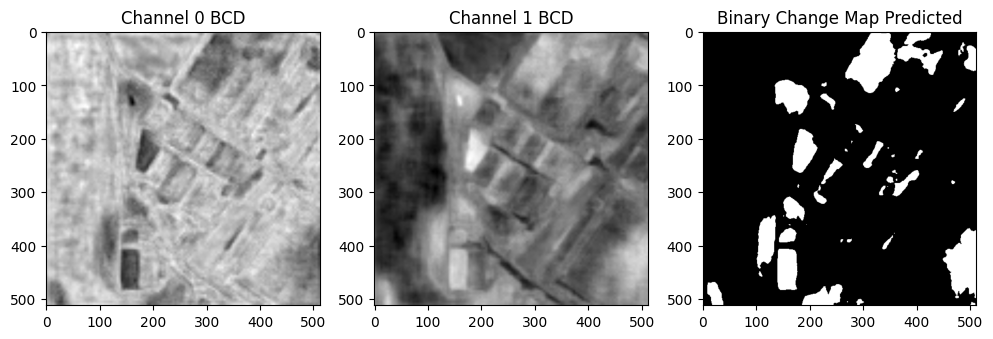

In [41]:
output_1, output_semantic_t1, output_semantic_t2 = deep_model(pre_change_imgs, post_change_imgs)

change_mask = torch.argmax(output_1, axis=1)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(output_1[0][0].cpu().detach().numpy(), cmap='gray')
axes[0].set_title('Channel 0 BCD')
axes[1].imshow(output_1[0][1].cpu().detach().numpy(), cmap='gray')
axes[1].set_title('Channel 1 BCD')
axes[2].imshow(change_mask[0].cpu().detach().numpy(), cmap='gray')
axes[2].set_title('Binary Change Map Predicted')
plt.show()

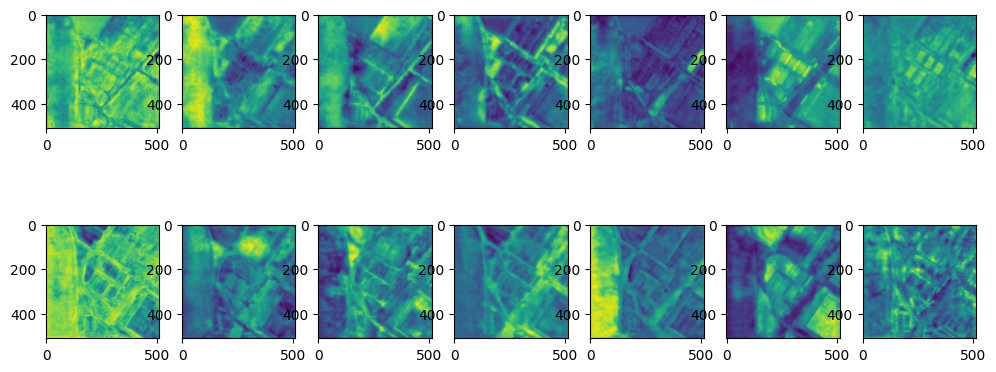

In [42]:
fig, axes = plt.subplots(2, 7, figsize=(12, 5))
for i in range(7):
    axes[0, i].imshow(output_semantic_t1[0][i].cpu().detach().numpy())
    axes[1, i].imshow(output_semantic_t2[0][i].cpu().detach().numpy())
plt.show()

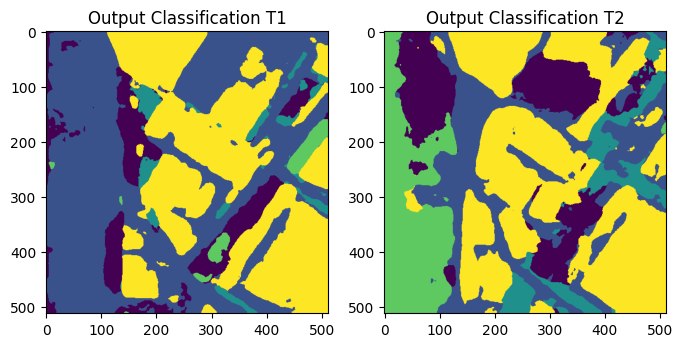

In [43]:
output_semantic_t1_pred = torch.argmax(output_semantic_t1, dim=1)
output_semantic_t2_pred = torch.argmax(output_semantic_t2, dim=1)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(output_semantic_t1_pred[0].cpu().detach().numpy())
axes[0].set_title('Output Classification T1')
axes[1].imshow(output_semantic_t2_pred[0].cpu().detach().numpy())
axes[1].set_title('Output Classification T2')

plt.show()

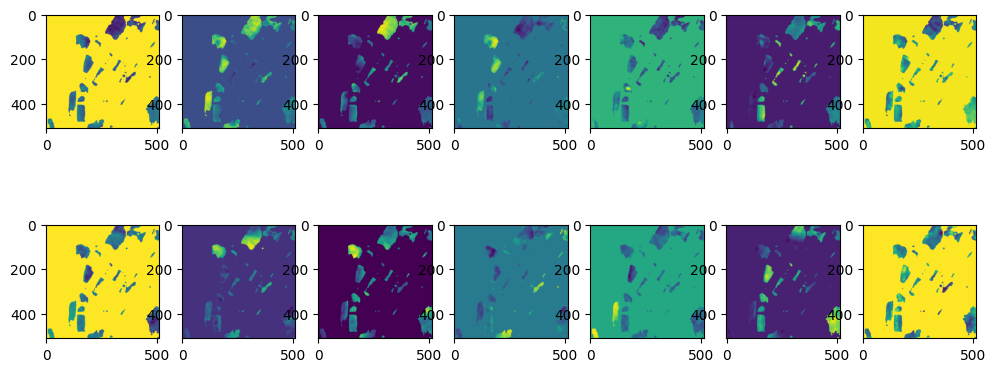

In [46]:
mask_0 = (change_mask == 0).unsqueeze(1).expand_as(output_semantic_t1)

output_semantic_t1[mask_0] = 0
output_semantic_t1[:, 0, :, :][mask_0[:, 0, :, :]] = 1

output_semantic_t2[mask_0] = 0
output_semantic_t2[:, 0, :, :][mask_0[:, 0, :, :]] = 1

fig, axes = plt.subplots(2, 7, figsize=(12, 5))
for i in range(7):
    axes[0, i].imshow(output_semantic_t1[0][i].cpu().detach().numpy())
    axes[1, i].imshow(output_semantic_t2[0][i].cpu().detach().numpy())
plt.show()

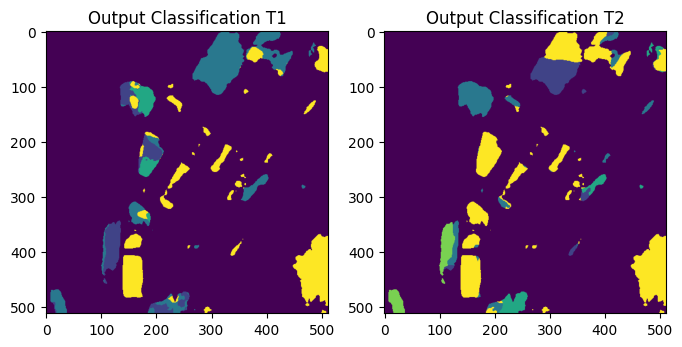

In [47]:
output_semantic_t1_pred = torch.argmax(output_semantic_t1, dim=1)
output_semantic_t2_pred = torch.argmax(output_semantic_t2, dim=1)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(output_semantic_t1_pred[0].cpu().detach().numpy())
axes[0].set_title('Output Classification T1')
axes[1].imshow(output_semantic_t2_pred[0].cpu().detach().numpy())
axes[1].set_title('Output Classification T2')

plt.show()